# Agentic AI - Turning functions into tools

## 1. Introduction

### 1.1. overview

In this lab, you will create a set of tools and give them to an LLM in two different ways:

1. **With a framework**: using LangChain's `init_chat_model` and `create_agent`, which run the whole tool-calling loop for you.
2. **Without a framework**: using the plain OpenAI SDK and a `for` loop that you write yourself, so you can see exactly what a framework does behind the scenes (parse tool calls, run the functions, send the results back).

You will see how the LLM requests tools to be used and how it chooses the right tools when they are relevant to its task.

### 🎯 1.2 Learning outcome

Apply tool-calling design patterns to agent workflows.

To achieve this you will give LLMs controlled access to Python functions via LangChain agents, implement parameter passing and the execution loop by hand, and validate multi-step outputs generated through tool orchestration.

## 2. Setup: Initialize environment and model

The API key is read from a `.env` file (or from the environment). Make sure it contains `OPENAI_API_KEY=...`.

In [1]:
import json
import dotenv

dotenv.load_dotenv()

True

### 2.1 Getting started with `init_chat_model`

`init_chat_model` is LangChain's provider-agnostic way of creating a chat model. You pass a `"provider:model"` string and get back a chat model object. This model will be the "brain" of every agent in this lab. To switch to another model or provider, you only change this string (the matching LangChain integration package must be installed).

In [3]:
from langchain.chat_models import init_chat_model

# Create the chat model used by all LangChain agents in this notebook
model = init_chat_model("openai:gpt-5.1")

## 3. Build your first tool

### 3.1 Defining your function

Now that you have set up your environment, it is time to create your first tool. Run the cell below to define a function that returns the current time as a string. Notice that this function includes a docstring explaining its purpose. This is important because LangChain uses the docstring as the tool **description** that the LLM reads when deciding whether to call it.

In [4]:
from datetime import datetime

def get_current_time():
    """
    Returns the current time as a string.
    """
    return datetime.now().strftime("%H:%M:%S")

In [5]:
get_current_time()

'19:02:04'

Great! Just as expected, the function returns a string that has your current time.

### 3.2 Turning your function into an LLM tool (with LangChain)

LangChain's `tool` function wraps a plain Python function into a tool object. It builds the tool's `name` from the function name, its `description` from the docstring, and its parameter schema from the function's type hints. Let's take a look:

In [13]:
from langchain.tools import tool

get_current_time_tool = tool(get_current_time)

print("name       :", get_current_time_tool.name)
print("description:", get_current_time_tool.description.strip())
print("args       :", get_current_time_tool.args)

name       : get_current_time
description: Returns the current time as a string.
args       : {}


Now let's create an **agent**. `create_agent` takes the chat model and a list of tools, and returns an agent that runs the tool-calling loop for you: call the model, execute any requested tool, feed the result back, and repeat until the model gives a final answer.

The input to the agent is a dictionary with a `messages` list. Each message has a `role` (e.g. `"user"`, `"assistant"`, `"system"`) and `content`.

Instead of `max_turns`, LangChain agents use `recursion_limit` (passed in `config`). It limits the number of steps of the agent graph and protects you from infinite tool-calling loops. Note that one tool round trip already takes a few steps (model call → tool execution → model call), so keep the limit comfortably above that.

In [15]:
from langchain.agents import create_agent

agent = create_agent(model=model, tools=[get_current_time_tool])

# Message structure
prompt = "الان ساعت حدودا چند است؟"
inputs = {"messages": [{"role": "user", "content": prompt}]}

result = agent.invoke(inputs, config={"recursion_limit": 10})

# See the LLM response
print(result["messages"][-1].text)

الان حدوداً ساعت ۷:۰۵ عصر است.


And just like that you've given your LLM access to tools! The agent turned your function into a tool that augmented the LLM's knowledge about the world.

### 3.3 Taking a closer look at the response

While the final message was just what was expected, there is actually a lot happening behind the scenes. `result["messages"]` holds the full conversation history:

* `HumanMessage`: your prompt
* `AIMessage` with `tool_calls`: the LLM asking for a tool to be run
* `ToolMessage`: the output of the tool, produced on your machine
* `AIMessage` (final): the answer, written with the tool output in context

The helper below prints these steps in an easy-to-read format.

In [17]:
def show_messages(result):
    """Pretty-print the steps of a LangChain agent run."""
    messages = result["messages"]
    for m in messages:
        if m.type == "human":
            print(f"👤 User: {m.text}\n")
        elif m.type == "ai":
            for call in m.tool_calls:
                print(f"🧠 LLM Action: {call['name']}({json.dumps(call['args'], ensure_ascii=False)})\n")
            if m.text:
                print(f"✅ Final Assistant Message:\n{m.text}\n")
        elif m.type == "tool":
            print(f"🔧 Tool Response [{m.name}]: {m.text}\n")

    sequence = [call["name"] for m in messages if m.type == "ai" for call in m.tool_calls]
    print("🧭 Tool Sequence:", " → ".join(sequence) if sequence else "(no tools used)")

show_messages(result)

👤 User: الان ساعت حدودا چند است؟

🧠 LLM Action: get_current_time({})

🔧 Tool Response [get_current_time]: 19:04:48

✅ Final Assistant Message:
الان حدوداً ساعت ۷:۰۵ عصر است.

🧭 Tool Sequence: get_current_time


As you can see, the LLM sent a message asking to use `get_current_time`. This was executed on your machine and sent back to the LLM. Finally, the LLM, having the full conversation history, used that information to give the final response. `create_agent` handled all the complexities of pulling out the tool call, executing it locally, and passing the result back to the LLM.

### 3.4 Without a framework: manually defining tools and the tool loop

The agent above is convenient, but what is really happening behind the scenes? Let's do it ourselves with the plain OpenAI SDK, no LangChain involved.

First, we have to describe each tool to the LLM using a JSON schema. Within this schema are several important parts:
* `name`: The name of the corresponding function that you defined locally
* `description`: A description that explains what the function does and is used by the LLM to help it decide when to use it
* `parameters`: If your function has parameters, they are described (JSON Schema) with the parameter name, type and a description of what it should be.

We also need a **registry**: a dictionary that maps each tool name to the real Python function, so that when the LLM asks for `"get_current_time"` we know what to run.

In [19]:
tools_schema = [{
    "type": "function",
    "function": {
        "name": "get_current_time",
        "description": "Returns the current time as a string.",
        "parameters": {
            "type": "object",
            "properties": {},
            "required": []
        }
    }
}]

# name -> real python function
registry = {"get_current_time": get_current_time}

Now let's make a single request and look at what the LLM sends back. When the model wants a tool, `finish_reason` is `"tool_calls"` and the message has a `tool_calls` list instead of text content. **Nothing has been executed yet** — the model only *asks* for the call; running it is our job.

In [21]:
from openai import OpenAI

openai_client = OpenAI()

messages = [{"role": "user", "content": "What time is it?"}]

response = openai_client.chat.completions.create(
    model="gpt-5.1",
    messages=messages,
    tools=tools_schema,
)

print(json.dumps(response.model_dump(), indent=2, default=str))

{
  "id": "gen-1790437292-eq0GXBdt2KQORsrbZE3L",
  "choices": [
    {
      "finish_reason": "tool_calls",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": null,
        "refusal": null,
        "role": "assistant",
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": [
          {
            "id": "call_isWUuAtAUWBUUbbOXXKQYLMn",
            "function": {
              "arguments": "{}",
              "name": "get_current_time"
            },
            "type": "function",
            "index": 0
          }
        ],
        "reasoning": null
      },
      "native_finish_reason": "completed"
    }
  ],
  "created": 1790437292,
  "model": "openai/gpt-5.1",
  "object": "chat.completion",
  "service_tier": "default",
  "system_fingerprint": null,
  "usage": {
    "completion_tokens": 21,
    "prompt_tokens": 44,
    "total_tokens": 65,
    "completion_tokens_details": {
      "accepted_prediction_token

Notice that in the `response` you can see `tool_calls` under `message`. The LLM is saying that it wants to call a tool, specifically `get_current_time`, with the (empty) arguments `{}`. Note that `arguments` arrives as a **JSON string**, so it must be parsed with `json.loads` before use.

A single request/response is not enough in general: after we send the tool result back, the model might answer, or it might request *more* tools (possibly several at once). So the real solution is a **loop**:

1. Send the messages to the LLM.
2. If the reply has no `tool_calls` → it is the final answer, stop.
3. Otherwise, append the assistant message, run **every** requested tool, and append one `tool` message per call (with the matching `tool_call_id`).
4. Go back to step 1, up to `max_turns` times.

Errors are also handled: if a tool crashes or the model asks for an unknown tool, the error text is sent back to the LLM as the tool result, so the model can recover instead of your program crashing.

In [23]:
def run_tool_loop(prompt, tools_schema, registry, model="gpt-5.1", max_turns=5, verbose=True):
    """A minimal agent: call the LLM, execute requested tools, repeat until it answers."""
    messages = [{"role": "user", "content": prompt}]
    tool_sequence = []

    for turn in range(1, max_turns + 1):
        response = openai_client.chat.completions.create(
            model=model,
            messages=messages,
            tools=tools_schema,
        )
        message = response.choices[0].message

        # No tool requested -> this is the final answer
        if not message.tool_calls:
            if verbose:
                print(f"✅ Final Assistant Message:\n{message.content}\n")
                print("🧭 Tool Sequence:", " → ".join(tool_sequence) if tool_sequence else "(no tools used)")
            messages.append({"role": "assistant", "content": message.content})
            return message.content, messages

        # Keep the assistant message (with its tool_calls) in the history
        messages.append(message.model_dump(exclude_none=True))

        # Execute EVERY requested tool call (the model may ask for several at once)
        for call in message.tool_calls:
            name = call.function.name
            try:
                if name not in registry:
                    raise KeyError(f"Unknown tool: {name}")
                args = json.loads(call.function.arguments or "{}")
                if verbose:
                    print(f"🧠 [turn {turn}] LLM Action: {name}({json.dumps(args, ensure_ascii=False)})")
                result = registry[name](**args)
            except Exception as e:
                result = f"Error: {type(e).__name__}: {e}"
            tool_sequence.append(name)
            if verbose:
                print(f"🔧 Tool Response [{name}]: {result}\n")

            # Each tool result must reference the id of the call it answers
            messages.append({
                "role": "tool",
                "tool_call_id": call.id,
                "content": str(result),
            })

    raise RuntimeError(f"No final answer after {max_turns} turns")

In [25]:
answer, history = run_tool_loop("What time is it?", tools_schema, registry)

🧠 [turn 1] LLM Action: get_current_time({})
🔧 Tool Response [get_current_time]: 19:18:49

✅ Final Assistant Message:
The current time is 19:18:49.

🧭 Tool Sequence: get_current_time


You have now implemented your own tool-calling loop. Compare the two approaches: with `create_agent` you pass Python functions and a `recursion_limit`, and the framework generates the schema and runs the loop; with the manual approach you write the schema, the registry and the loop yourself, which gives you full control (logging, error handling, permissions, retries) at the cost of more code.

## 4. Giving the LLM more tools

Now that you've explored how tools are created and how they are processed locally, let's create a few more tools.

### 4.1 Three new tools

You will define three new tools for your LLM:

- **Weather Tool (`get_weather_from_ip`)**
  Detects the user's location and returns the current, the high, and the low temperature (in °C) using external API calls: one to detect your location from your IP address and another to a weather API to get the current weather.

- **File Writing Tool (`write_txt_file`)**
  Creates a text file with the specified content in your local environment. The function takes two arguments, `file_path` and `content`.

- **QR Code Generator (`generate_qr_code`)**
  Generates a QR code image from data, with an embedded image in the center. The function takes three arguments: `data`, `filename`, and `image_path`.

Run the cell below to import some new packages and define the tools.

In [27]:
import requests
import qrcode
from qrcode.image.styledpil import StyledPilImage


def get_weather_from_ip():
    """
    Gets the current, high, and low temperature in Celsius for the user's
    location (detected from their IP address) and returns it as a string.
    """
    # Get location coordinates from the IP address
    ip_info = requests.get('https://geolocation-db.com/json/').json()
    lat, lon = ip_info['latitude'], ip_info['longitude']

    # Set parameters for the weather API call
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m",
        "daily": "temperature_2m_max,temperature_2m_min",
        "timezone": "auto"
    }

    # Get weather data
    weather_data = requests.get("https://api.open-meteo.com/v1/forecast", params=params).json()

    # Format and return the simplified string
    return (
        f"Current: {weather_data['current']['temperature_2m']}°C, "
        f"High: {weather_data['daily']['temperature_2m_max'][0]}°C, "
        f"Low: {weather_data['daily']['temperature_2m_min'][0]}°C"
    )


def write_txt_file(file_path: str, content: str):
    """
    Write a string into a .txt file (overwrites if exists).

    Args:
        file_path (str): Destination path.
        content (str): Text to write.

    Returns:
        str: Path to the written file.
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(content)
    return file_path


def generate_qr_code(data: str, filename: str, image_path: str):
    """
    Generate a QR code PNG with an image embedded in its center.

    Args:
        data (str): Text or URL to encode.
        filename (str): Name for the output PNG file (without extension).
        image_path (str): Path to the image to embed in the QR code.
    """
    qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
    qr.add_data(data)

    img = qr.make_image(image_factory=StyledPilImage, embedded_image_path=image_path)
    output_file = f"{filename}.png"
    img.save(output_file)

    return f"QR code saved as {output_file} containing: {data[:50]}..."

In [29]:
get_weather_from_ip()

'Current: 25.9°C, High: 30.3°C, Low: 19.7°C'

### 4.2 Using your new tools (LangChain agent)

Now it's time to use your new tools! You will create one agent that has **all** the tools. The LLM will choose the appropriate tool based on the prompt you send it. Let's define a small helper to run the agent, and start with the `get_weather_from_ip` tool.

In [31]:
all_tools = [
    tool(get_current_time),
    tool(get_weather_from_ip),
    tool(write_txt_file),
    tool(generate_qr_code),
]

agent = create_agent(model=model, tools=all_tools)

def ask_agent(prompt, recursion_limit=25):
    inputs = {"messages": [{"role": "user", "content": prompt}]}
    result = agent.invoke(inputs)
    show_messages(result)
    return result

In [33]:
prompt = "می‌تونی وضعیت آب‌وهوا رو برای محل فعلی من بگی؟"

result = ask_agent(prompt)

👤 User: می‌تونی وضعیت آب‌وهوا رو برای محل فعلی من بگی؟

🧠 LLM Action: get_weather_from_ip({})

🔧 Tool Response [get_weather_from_ip]: Current: 25.9°C, High: 30.3°C, Low: 19.7°C

✅ Final Assistant Message:
الان دمای هوا در محل شما حدود ۲۵.۹ درجه سانتی‌گراد است.  
بیشترین دمای امروز حدود ۳۰.۳ درجه و کمترین آن حدود ۱۹.۷ درجه سانتی‌گراد خواهد بود.

🧭 Tool Sequence: get_weather_from_ip


You can see that the LLM appropriately chose the correct tool based on the intent of the prompt, even though it had access to other tools.

Now, run the cell below to prompt the LLM to create a note for you.

In [35]:
prompt = "می‌تونی یه فایل متنی به اسم reminders.txt برام بسازی که یادم بندازه فردا ساعت ۷ عصر به علی زنگ بزنم؟"

result = ask_agent(prompt)

👤 User: می‌تونی یه فایل متنی به اسم reminders.txt برام بسازی که یادم بندازه فردا ساعت ۷ عصر به علی زنگ بزنم؟

🧠 LLM Action: write_txt_file({"content": "یادآوری: فردا ساعت ۷ عصر به علی زنگ بزن.", "file_path": "reminders.txt"})

🔧 Tool Response [write_txt_file]: reminders.txt

✅ Final Assistant Message:
فایل `reminders.txt` با محتوای زیر ساخته شد:

یادآوری: فردا ساعت ۷ عصر به علی زنگ بزن.

اگر می‌خواهی متنش را عوض کنم یا چند تا یادآوری دیگر هم اضافه شود بگو تا ویرایشش کنم.

🧭 Tool Sequence: write_txt_file


And now you have a text file with your reminder in it. You can see that the LLM passed the correct arguments to the tool, the tool ran locally, and then it printed a response that the action was completed. You can even open the text file and read the contents to make sure that it now exists.

In [37]:
with open('reminders.txt', 'r', encoding='utf-8') as file:
    contents = file.read()
    print(contents)

یادآوری: فردا ساعت ۷ عصر به علی زنگ بزن.


Finally, let's use the QR code generation tool to make a neat QR code that takes users to the class.vision website.

Run the cell below to create the QR code.

In [39]:
prompt = """Make a QR code for me using my company's logo that goes to https://class.vision/
The logo is located at `class.vision.png`. the output must be qr_out.png"""

result = ask_agent(prompt)

👤 User: Make a QR code for me using my company's logo that goes to https://class.vision/
The logo is located at `class.vision.png`. the output must be qr_out.png

🧠 LLM Action: generate_qr_code({"data": "https://class.vision/", "filename": "qr_out", "image_path": "class.vision.png"})

🔧 Tool Response [generate_qr_code]: QR code saved as qr_out.png containing: https://class.vision/...

✅ Final Assistant Message:
I’ve generated the QR code as requested.

- URL encoded: `https://class.vision/`
- Center image: `class.vision.png`
- Output file: `qr_out.png`

You can now use `qr_out.png` in your materials.

🧭 Tool Sequence: generate_qr_code


The LLM also successfully passed the correct arguments to the function, and then that information was used to run your function and create the QR code. Take a look at the QR code by running the cell below and try it out to see if it takes you to the website.

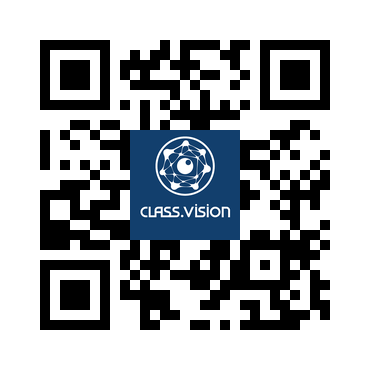

In [41]:
from IPython.display import Image, display

# Display image directly
Image('qr_out.png')

### 4.3 Using multiple tools at once

Lastly, it's important to remember that LLMs can use multiple tools and go through a sequence of tool calls to accomplish multiple things. Let's use your tools and examine the messages to see what happens. You will use a complex prompt:

> Can you help me create a qr code that goes to class.vision from the image class.vision.png? Also write me a txt note with the current weather please.

This prompt requires a good amount of logic to understand what to call and when. For example, although you ask it to write a text note first and then describe the contents, the LLM will need the weather information first to pass it to the text note. If the LLM asked to use `write_txt_file` first, it would not have the information from `get_weather_from_ip`. This is a good example of the power of LLMs to parse natural language and use appropriate tools in the right order to accomplish a wide variety of tasks.

<div style="background-color: #ffe4e1; padding: 12px; border-radius: 6px; color: black;">

<h4>🔍 What to Notice:</h4>

<ul>
  <li>The LLM <b>automatically chooses</b> which tool to use based on the user request</li>
  <li><b>Parameters are inferred</b> from the user's message (like file names, content, URLs)</li>
  <li>Each tool <b>returns information</b> that the LLM incorporates into its response</li>
  <li>The model can request <b>several tool calls in one turn</b> when they are independent of each other</li>
  <li>The conversation feels <b>natural</b> despite complex operations happening behind the scenes</li>
</ul>

</div>

In [43]:
prompt = "Can you help me create a qr code that goes to class.vision from the image class.vision.png? Also write me a txt note with the current weather please."

result = ask_agent(prompt)

👤 User: Can you help me create a qr code that goes to class.vision from the image class.vision.png? Also write me a txt note with the current weather please.

🧠 LLM Action: generate_qr_code({"data": "https://class.vision", "filename": "class_vision_qr", "image_path": "class.vision.png"})

🧠 LLM Action: get_weather_from_ip({})

🧠 LLM Action: get_current_time({})

🔧 Tool Response [generate_qr_code]: QR code saved as class_vision_qr.png containing: https://class.vision...

🔧 Tool Response [get_weather_from_ip]: Current: 25.9°C, High: 30.3°C, Low: 19.7°C

🔧 Tool Response [get_current_time]: 19:27:06

🧠 LLM Action: write_txt_file({"content": "Note created at: 19:27:06\nCurrent weather at your location:\n- Current temperature: 25.9°C\n- High: 30.3°C\n- Low: 19.7°C\n", "file_path": "weather_note.txt"})

🔧 Tool Response [write_txt_file]: weather_note.txt

✅ Final Assistant Message:
Here’s what I’ve done for you:

1. **QR Code**
   - Generated a QR code that links to `https://class.vision`.
   

And just like that, you see from the tool sequence that it called the tools in the correct order to accomplish the task, and then summarized the result in the order that you requested it.

### 4.4 The same task without a framework

To see that the framework adds no magic, let's run the same multi-tool prompt with our own `run_tool_loop`. We only need the JSON schemas for the new tools and a registry with all four functions. Watch the verbose log: when the LLM asks for several independent tools in one turn, the loop executes all of them, and the dependent step (`write_txt_file`, which needs the weather text) comes in a later turn.

In [45]:
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "get_current_time",
            "description": "Returns the current time as a string.",
            "parameters": {"type": "object", "properties": {}, "required": []},
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_weather_from_ip",
            "description": "Gets the current, high, and low temperature in Celsius for the user's location (detected from their IP address) and returns it as a string.",
            "parameters": {"type": "object", "properties": {}, "required": []},
        },
    },
    {
        "type": "function",
        "function": {
            "name": "write_txt_file",
            "description": "Write a string into a .txt file (overwrites if exists). Returns the path to the written file.",
            "parameters": {
                "type": "object",
                "properties": {
                    "file_path": {"type": "string", "description": "Destination path."},
                    "content": {"type": "string", "description": "Text to write."},
                },
                "required": ["file_path", "content"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "generate_qr_code",
            "description": "Generate a QR code PNG with an image embedded in its center.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "Text or URL to encode."},
                    "filename": {"type": "string", "description": "Name for the output PNG file (without extension)."},
                    "image_path": {"type": "string", "description": "Path to the image to embed in the QR code."},
                },
                "required": ["data", "filename", "image_path"],
            },
        },
    },
]

registry = {
    "get_current_time": get_current_time,
    "get_weather_from_ip": get_weather_from_ip,
    "write_txt_file": write_txt_file,
    "generate_qr_code": generate_qr_code,
}

In [47]:
prompt = "Can you help me create a qr code that goes to class.vision from the image class.vision.png? Also write me a txt note with the current weather please."

answer, history = run_tool_loop(prompt, tools_schema, registry, max_turns=10)

🧠 [turn 1] LLM Action: generate_qr_code({"data": "https://class.vision", "filename": "class_vision_qr", "image_path": "class.vision.png"})
🔧 Tool Response [generate_qr_code]: QR code saved as class_vision_qr.png containing: https://class.vision...

🧠 [turn 1] LLM Action: get_weather_from_ip({})
🔧 Tool Response [get_weather_from_ip]: Current: 25.3°C, High: 30.3°C, Low: 19.7°C

🧠 [turn 1] LLM Action: get_current_time({})
🔧 Tool Response [get_current_time]: 19:32:26

🧠 [turn 2] LLM Action: write_txt_file({"content": "Weather note (generated at 19:32:26):\nCurrent: 25.3°C\nHigh: 30.3°C\nLow: 19.7°C\n", "file_path": "weather_note.txt"})
🔧 Tool Response [write_txt_file]: weather_note.txt

✅ Final Assistant Message:
Here’s what I’ve done for you:

1. QR code  
   - Generated a QR code that links to: `https://class.vision`  
   - File created: `class_vision_qr.png`  
   - It uses `class.vision.png` as the embedded center image.

2. Weather note (.txt file)  
   - Created a text file with the c

### Model Options

You can experiment with different models when running these tool-calling workflows. Each model offers a different balance of capability, cost, and speed. With `init_chat_model` you only change the `"provider:model"` string, for example:

- **`openai:gpt-5.1`** — the model used in this notebook; strong reasoning, good for multi-step tool use
- **`openai:gpt-4.1`** — strong reasoning performance, good for complex tasks
- **`openai:gpt-4.1-mini`** — lighter, faster, and cheaper than full GPT-4.1
- **`openai:gpt-4o`** — optimized for speed and general use

(For the framework-free loop, pass the bare model name to the OpenAI SDK, e.g. `model="gpt-4.1-mini"`.)

Choosing a model depends on your goals:
- Use smaller models for fast, low-cost prototyping
- Switch to stronger models when tasks require better reasoning or multi-step orchestration


### Final Takeaways

- Tool calling lets LLMs go beyond text generation—they can now use functions as part of their reasoning.
- Clear, well-documented functions (with precise docstrings and type hints) help the model know when and how to use each tool.
- LangChain's `init_chat_model` + `create_agent` turn Python functions into tool schemas and run the multi-step loop for you; `recursion_limit` protects against endless loops.
- Under the hood, an agent is just a loop: call the LLM → if it returns `tool_calls`, run each tool and send back `tool` messages with the matching `tool_call_id` → repeat until there is a final answer. Writing it yourself gives full control over errors, logging and safety.
- Choosing the right model matters: smaller models are faster and cheaper for simple tasks, while stronger models are better for reasoning-heavy workflows.
- Watching the conversation flow (prompts, tool calls, results, final response) is essential for debugging and improving agentic behaviors.

With these elements in place, you now have the foundation to design agents that combine LLM reasoning with external tools to complete more complex tasks.

<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b; font-family:system-ui,-apple-system,Segoe UI,Roboto,Ubuntu,Cantarell,Noto Sans,sans-serif;">

🎉 <strong>Congratulations!</strong>

You've completed the lab on **turning functions into tools** with LangChain agents and with a hand-written tool loop.
Along the way, <strong>you</strong> exposed Python functions as tools, let the LLM choose and call them, implemented the execution loop yourself, and inspected multi-step tool orchestration.

With these skills, <strong>you</strong> can design agentic workflows that combine LLM reasoning with real actions—reliable, auditable, and easy to extend. 🌟

</div>